#**Iris Flower Clustering & Visualization**

**Load the Iris dataset.**

**Convert it into a Pandas DataFrame.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)
df = iris.data.copy()
df['species'] = iris.target
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))


**Explore the dataset.**

In [2]:
print("First 5 rows:\n", df.head())
print("\nShape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescribe:\n", df.describe())
print("\nSpecies distribution:\n", df['species_name'].value_counts())

X = iris.data.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Shape: (150, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-nu

**Apply K-Means clustering.**
**Use the Elbow Method to select the optimal number of clusters.**

In [3]:


inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['cluster'] = cluster_labels

**Reduce the dataset to 2 dimensions using PCA.**

In [4]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

print("\nExplained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("Total variance captured by 2 PCs: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100))



Explained variance ratio (PC1, PC2): [0.72962445 0.22850762]
Total variance captured by 2 PCs: 95.81%


#**Visualize:**
  
**Original data (using selected features)**

**K-Means clusters**

**PCA-transformed data**

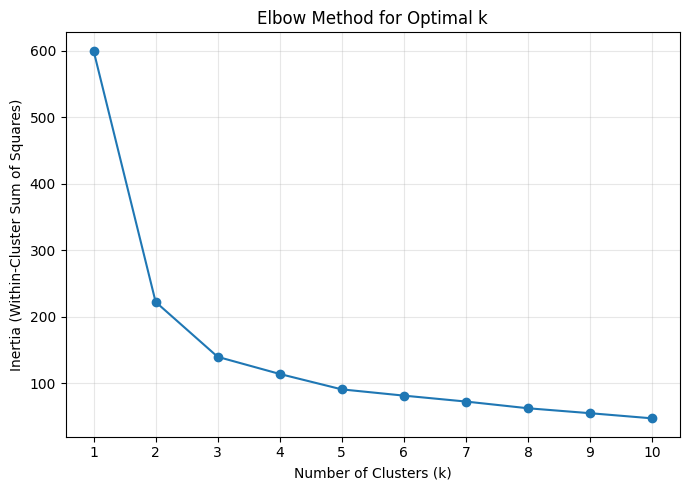

In [5]:


plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=150)
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Original data using two real features (petal length vs width),
# colored by TRUE species
scatter1 = axes[0].scatter(
    df['petal length (cm)'], df['petal width (cm)'],
    c=df['species'], cmap='viridis', edgecolor='k', s=50
)
axes[0].set_title("Original Data (True Species)\nPetal Length vs Petal Width")
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Species")
axes[0].add_artist(legend1)

# Panel B: Same two features, colored by K-MEANS cluster assignment
scatter2 = axes[1].scatter(
    df['petal length (cm)'], df['petal width (cm)'],
    c=df['cluster'], cmap='viridis', edgecolor='k', s=50
)
axes[1].set_title("K-Means Clusters (k=3)\nPetal Length vs Petal Width")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Cluster")
axes[1].add_artist(legend2)

# Panel C: PCA-transformed data, colored by K-Means cluster
scatter3 = axes[2].scatter(
    df['pca1'], df['pca2'],
    c=df['cluster'], cmap='viridis', edgecolor='k', s=50
)
axes[2].set_title("PCA (2 Components)\nColored by K-Means Cluster")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
legend3 = axes[2].legend(*scatter3.legend_elements(), title="Cluster")
axes[2].add_artist(legend3)

plt.tight_layout()
plt.savefig("comparison_plots.png", dpi=150)
plt.close()



In [6]:
crosstab = pd.crosstab(df['species_name'], df['cluster'])
print("\nCluster vs True Species Crosstab:\n", crosstab)

# Save final dataframe
df.to_csv("iris_with_clusters.csv", index=False)

print("\nDone. Files saved: elbow_method.png, comparison_plots.png, iris_with_clusters.csv")



Cluster vs True Species Crosstab:
 cluster        0   1   2
species_name            
setosa         0  50   0
versicolor    39   0  11
virginica     14   0  36

Done. Files saved: elbow_method.png, comparison_plots.png, iris_with_clusters.csv
